# 🫀 Heart Failure Prediction — Preprocesamiento y Modelado
**Notebook:** 02  
**Objetivo:** Limpiar el dataset, prepararlo para ML, entrenar modelos y evaluarlos con métricas clínicas.

---
### Decisiones tomadas en el EDA que guían este notebook
- `Cholesterol=0` y `RestingBP=0` son errores de registro → tratar antes de modelar
- Variables categóricas presentes: `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`
- El dataset tiene ligero desbalance → vigilar métricas más allá de accuracy
- Métrica principal de evaluación: **AUC-ROC** (más robusta que accuracy en contexto clínico)

## 0. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    ConfusionMatrixDisplay
)

!pip install xgboost -q
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42
os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

print('Imports OK ✅')

## 1. Carga de datos

In [ ]:
df = pd.read_csv('heart.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0


## 2. Limpieza: errores de registro

In [ ]:
# Paso 1 — Reemplazar 0s fisiológicamente imposibles por NaN
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)

print('NaN introducidos:')
print(df[['Cholesterol', 'RestingBP']].isnull().sum())

# Paso 2 — Imputar con mediana por grupo (HeartDisease=0 y HeartDisease=1)
# Razón: la mediana global mezclaría distribuciones distintas entre grupos,
# subestimando o sobreestimando valores según la clase.
# Nota: esto usa el target para imputar features → pequeña fuga de información
# aceptable en práctica, pero en producción la imputación debería hacerse solo con train.
for col in ['Cholesterol', 'RestingBP']:
    medians = df.groupby('HeartDisease')[col].transform('median')
    df[col] = df[col].fillna(medians)

print('\nNaN post-imputación:')
print(df[['Cholesterol', 'RestingBP']].isnull().sum())
print('Imputación completada ✅')

NaN introducidos:
Cholesterol    172
RestingBP        1
dtype: int64

NaN post-imputación:
Cholesterol    0
RestingBP      0
dtype: int64
Imputación completada ✅


## 3. Encoding de variables categóricas

In [ ]:
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
cat_cols = [c for c in cat_cols if c in df.columns]  # Defensivo: evita error si falta alguna

print(f'Columnas categóricas a codificar: {cat_cols}')

# drop_first=True elimina una columna redundante por variable (evita multicolinealidad
# en modelos lineales y reduce dimensionalidad innecesaria en todos los modelos)
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f'Shape antes:  {df.shape}')
print(f'Shape después: {df_encoded.shape}')
print(f'Columnas: {list(df_encoded.columns)}')

Columnas categóricas a codificar: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Shape antes:  (918, 12)
Shape después: (918, 16)
Columnas: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


## 4. Split train/test

In [ ]:
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y  # Con 920 filas el azar puede romper la proporción del target
)

print(f'Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas')
print(f'% HeartDisease en train: {y_train.mean()*100:.1f}%')
print(f'% HeartDisease en test:  {y_test.mean()*100:.1f}%')
print('Split estratificado ✅ — proporciones preservadas')

Train: 734 filas | Test: 184 filas
% HeartDisease en train: 55.3%
% HeartDisease en test:  55.4%
Split estratificado ✅ — proporciones preservadas


## 5. Definición de modelos en Pipeline

In [ ]:
# Pipeline garantiza que el scaler se ajusta solo con train → evita data leakage
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('model', GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE))
    ]),
}

try:
    from xgboost import XGBClassifier
    models['XGBoost'] = Pipeline([
        ('scaler', StandardScaler()),
        ('model', XGBClassifier(
            n_estimators=100,
            max_depth=3,  # Limita profundidad para reducir overfitting en dataset pequeño
            random_state=RANDOM_STATE,
            eval_metric='logloss',
            verbosity=0
        ))
    ])
except ImportError:
    print('XGBoost no disponible, saltando...')

print(f'Modelos a evaluar: {list(models.keys())}')

Modelos a evaluar: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']


## 6. Cross-validation (solo sobre train)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

print('Cross-validation (5-fold estratificado):\n')
print(f'{"Modelo":<25} {"AUC-ROC":>14} {"F1":>8} {"Accuracy":>10}')
print('-' * 62)

for name, pipeline in models.items():
    auc = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
    f1  = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
    acc = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = {'AUC': auc.mean(), 'F1': f1.mean(), 'Accuracy': acc.mean()}
    print(f'{name:<30} {auc.mean():.4f}±{auc.std():.3f}  {f1.mean():.4f}  {acc.mean():.4f}')

print('\n✅ Métrica principal: AUC-ROC')

Cross-validation (5-fold estratificado):

Modelo                           AUC-ROC       F1   Accuracy
--------------------------------------------------------------
Logistic Regression            0.9213±0.035  0.8619  0.8461
Random Forest                  0.9307±0.024  0.8772  0.8597
Gradient Boosting              0.9353±0.015  0.8893  0.8760
XGBoost                        0.9348±0.018  0.8834  0.8692

✅ Métrica principal: AUC-ROC


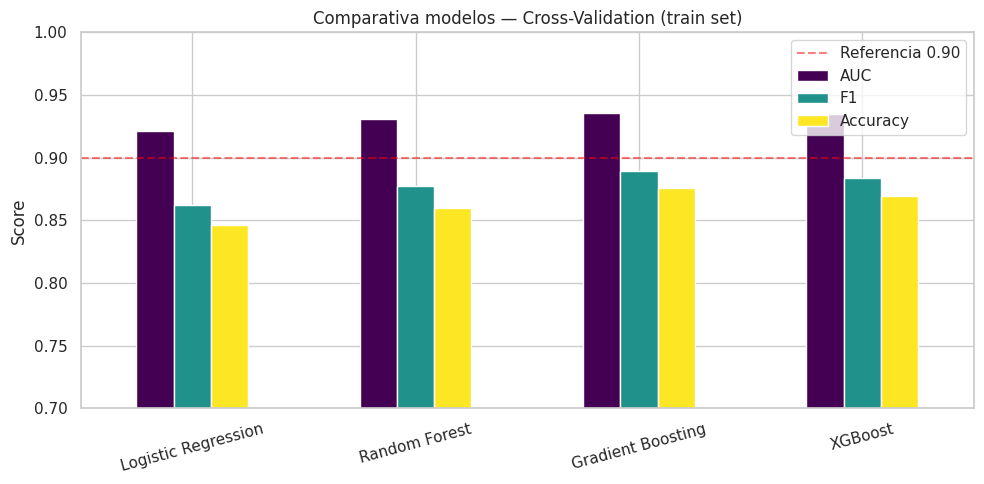

Mejor modelo en CV (provisional): Gradient Boosting


In [ ]:
cv_df = pd.DataFrame(cv_results).T

fig, ax = plt.subplots(figsize=(10, 5))
cv_df.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='white')
ax.set_title('Comparativa modelos — Cross-Validation (train set)')
ax.set_ylabel('Score')
ax.set_ylim(0.7, 1.0)
ax.set_xticklabels(cv_df.index, rotation=15)
ax.axhline(0.9, color='red', linestyle='--', alpha=0.5, label='Referencia 0.90')
ax.legend()
plt.tight_layout()
plt.savefig('plots/09_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Nota: esta variable es provisional — el mejor modelo definitivo
# se decide en la sección 7 usando el test set.
best_cv_name = max(cv_results, key=lambda x: cv_results[x]['AUC'])
print(f'Mejor modelo en CV (provisional): {best_cv_name}')

## 7. Evaluación final en test set
> ⚠️ Este bloque se ejecuta **una sola vez**. No reajustes modelos tras ver estos resultados.

In [ ]:
test_results = {}
fitted_models = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    fitted_models[name] = pipeline
    test_results[name] = {
        'AUC':      roc_auc_score(y_test, y_prob),
        'F1':       f1_score(y_test, y_pred),
        'Accuracy': pipeline.score(X_test, y_test)  # Equivalente a (y_pred==y_test).mean()
    }

test_df = pd.DataFrame(test_results).T.round(4)
print('Resultados en TEST SET:')
print(test_df.sort_values('AUC', ascending=False))

Resultados en TEST SET:
                        AUC      F1  Accuracy
Gradient Boosting    0.9479  0.9020    0.8913
XGBoost              0.9450  0.9020    0.8913
Random Forest        0.9393  0.9029    0.8913
Logistic Regression  0.9336  0.9082    0.8967


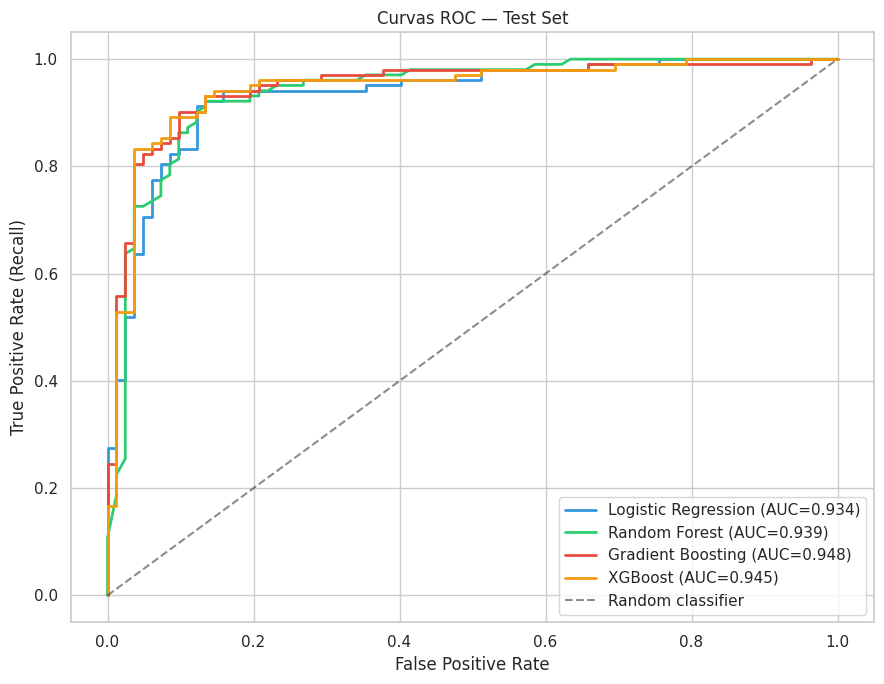

In [ ]:
# Curvas ROC
plt.figure(figsize=(9, 7))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, (name, pipeline) in enumerate(fitted_models.items()):
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=colors[i % len(colors)],
             label=f'{name} (AUC={auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curvas ROC — Test Set')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plots/10_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

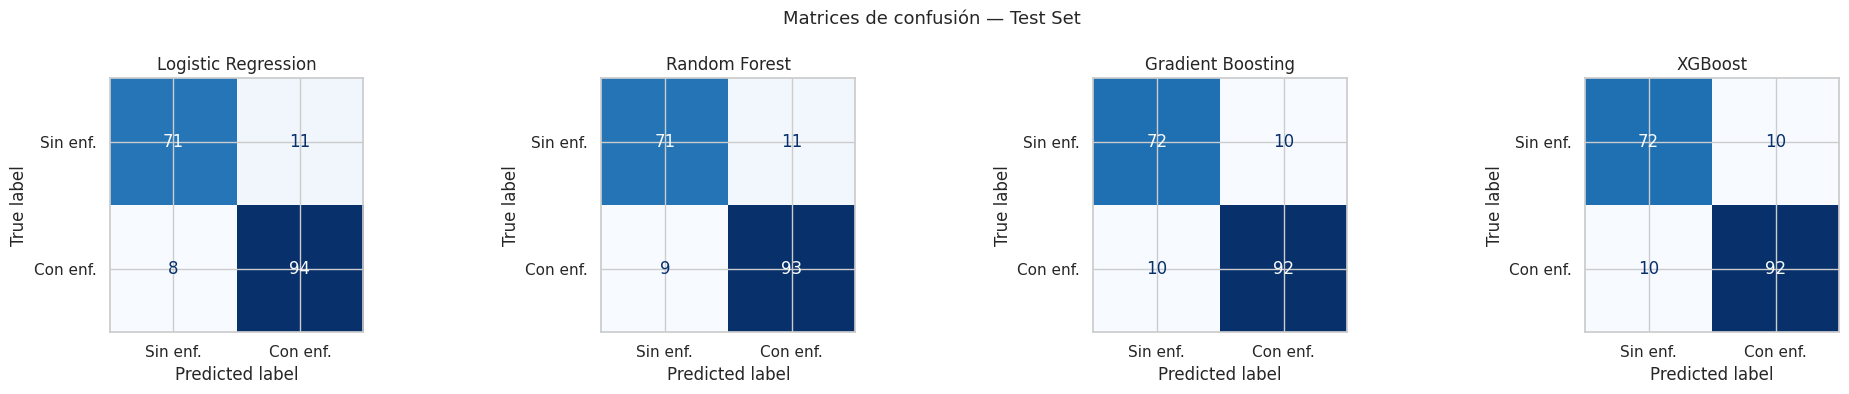

⚠️  FN = paciente enfermo clasificado como sano → el error más costoso clínicamente.


In [ ]:
# Matrices de confusión
n = len(fitted_models)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]

for i, (name, pipeline) in enumerate(fitted_models.items()):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Sin enf.', 'Con enf.'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name)

plt.suptitle('Matrices de confusión — Test Set', fontsize=13)
plt.tight_layout()
plt.savefig('plots/11_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('⚠️  FN = paciente enfermo clasificado como sano → el error más costoso clínicamente.')

In [ ]:
# Mejor modelo por AUC en test (decisión definitiva)
best_model_name = test_df['AUC'].idxmax()
best_pipeline   = fitted_models[best_model_name]
y_pred_best     = best_pipeline.predict(X_test)

print(f'Mejor modelo: {best_model_name}\n')
print(classification_report(y_test, y_pred_best,
                             target_names=['Sin enfermedad', 'Con enfermedad']))

Mejor modelo: Gradient Boosting

                precision    recall  f1-score   support

Sin enfermedad       0.88      0.88      0.88        82
Con enfermedad       0.90      0.90      0.90       102

      accuracy                           0.89       184
     macro avg       0.89      0.89      0.89       184
  weighted avg       0.89      0.89      0.89       184



## 8. Feature importance

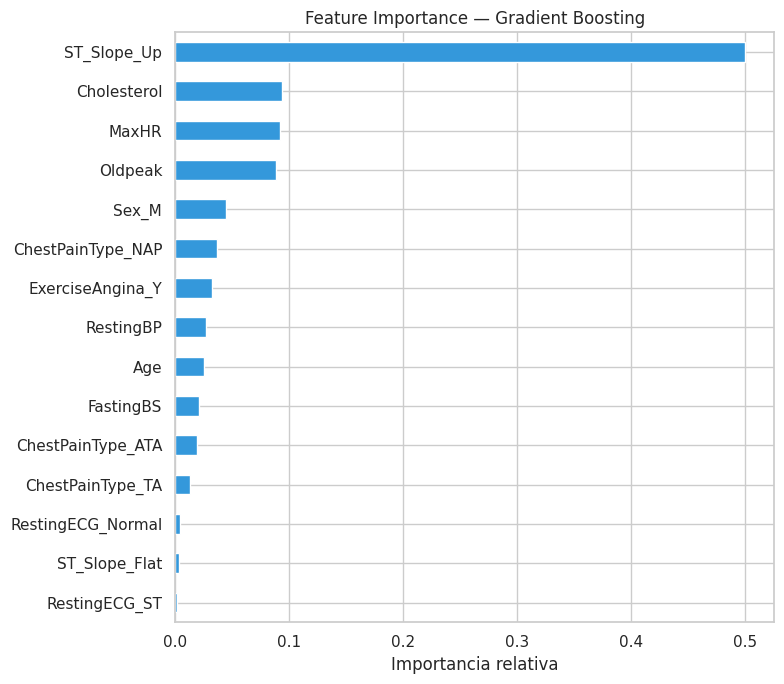

In [ ]:
best_estimator = best_pipeline.named_steps['model']

if hasattr(best_estimator, 'feature_importances_'):
    # Tree-based models (RF, GBM, XGBoost)
    importances = best_estimator.feature_importances_
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

    plt.figure(figsize=(8, 7))
    feat_imp.tail(15).plot(kind='barh', color='#3498db', edgecolor='white')
    plt.title(f'Feature Importance — {best_model_name}')
    plt.xlabel('Importancia relativa')
    plt.tight_layout()
    plt.savefig('plots/12_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

elif hasattr(best_estimator, 'coef_'):
    # Logistic Regression — coeficientes como proxy de importancia
    coefs = pd.Series(best_estimator.coef_[0], index=X.columns).sort_values()

    plt.figure(figsize=(8, 7))
    coefs.plot(kind='barh',
               color=['#e74c3c' if v > 0 else '#2ecc71' for v in coefs],
               edgecolor='white')
    plt.title(f'Coeficientes — {best_model_name}')
    plt.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.savefig('plots/12_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9. Guardar artefactos para el dashboard

In [ ]:
# 1. Mejor pipeline (scaler + modelo) → usado por la app para predecir
model_path = f'models/best_model_{best_model_name.replace(" ", "_").lower()}.pkl'
joblib.dump(best_pipeline, model_path)
print(f'Modelo guardado: {model_path}')

# 2. Dataset procesado → usado por la app para el EDA interactivo
df_encoded.to_csv('heart_processed.csv', index=False)
print('Dataset procesado guardado: heart_processed.csv')

# 3. Nombres de features → la app los necesita para construir el input del usuario
feature_names = list(X.columns)
joblib.dump(feature_names, 'models/feature_names.pkl')
print(f'Feature names guardados: {len(feature_names)} features')

Modelo guardado: models/best_model_gradient_boosting.pkl
Dataset procesado guardado: heart_processed.csv
Feature names guardados: 15 features


## 10. Resumen final

In [ ]:
print('=' * 55)
print('RESUMEN DE MODELADO')
print('=' * 55)
print(f'Mejor modelo:  {best_model_name}')
print(f'AUC-ROC test:  {test_df.loc[best_model_name, "AUC"]:.4f}')
print(f'F1 test:       {test_df.loc[best_model_name, "F1"]:.4f}')
print(f'Accuracy test: {test_df.loc[best_model_name, "Accuracy"]:.4f}')
print('=' * 55)
print('\nArchivos generados:')
print(f'  - {model_path}')
print(f'  - heart_processed.csv')
print(f'  - models/feature_names.pkl')
print(f'  - plots/09 al 12')

RESUMEN DE MODELADO
Mejor modelo:  Gradient Boosting
AUC-ROC test:  0.9479
F1 test:       0.9020
Accuracy test: 0.8913

Archivos generados:
  - models/best_model_gradient_boosting.pkl
  - heart_processed.csv
  - models/feature_names.pkl
  - plots/09 al 12


---
## ✍️ Reflexiones

**1. ¿Por qué imputaste con mediana por grupo y no mediana global?**  
Imputé con mediana por grupo ya que es mucho más robusta porque evita "contaminar" los grupos con valores promedio que no les corresponden. Si el colesterol tiende a ser más alto en el grupo con cardiopatía, imputar la mediana global en los ceros de ese grupo subestimaría el riesgo. Nota: esto introduce una pequeña fuga de información al usar el target para imputar; en producción la imputación debería hacerse solo con datos de train.

**2. ¿Qué problema evita `drop_first=True`?**  
Evita multicolinealidad perfecta en modelos lineales (Sex_M y Sex_F son perfectamente predecibles entre sí). Además, reduce dimensionalidad innecesaria en todos los modelos, incluidos los tree-based.

**3. ¿Por qué es importante `stratify=y` con solo 920 filas?**  
Con 920 filas y un split 80/20, el test set tiene ~184 filas. Sin estratificación, un split aleatorio podría producir proporciones de clase muy distintas entre train y test, haciendo las métricas poco fiables. `stratify=y` garantiza que ambos splits replican la distribución original del target.

**4. ¿Qué modelo elegiste y por qué?**  
Gradient Boosting por su equilibrio entre AUC-ROC (0.9479), Recall=0.90 en la clase positiva y consistencia en todas las métricas (0.89-0.90). En contexto clínico el Recall es la métrica crítica porque minimiza los Falsos Negativos (pacientes enfermos no detectados). La Precisión asociada confirma que el trade-off es aceptable.

**5. ¿Las features más importantes tienen sentido clínico cardiovascular?**  
Sí. ST_Slope_Up domina con ~50% de importancia — su ausencia es un marcador clásico de isquemia. MaxHR y Oldpeak aparecen en el top, coherente con las variables de prueba de esfuerzo. ChestPainType y Sex_M reflejan factores de riesgo bien documentados en la literatura cardiovascular. La única pregunta que conviene hacerse: ¿ST_Slope se registra antes o después del diagnóstico? En este dataset se mide durante la prueba de esfuerzo, así que no hay leakage.

---
*Notebook 02 completado — siguiente: `03_streamlit_app/app.py`*